# Oracle from Shor's algorithm

#TODO describe project

In [1]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QFT
import math
import shors_alg

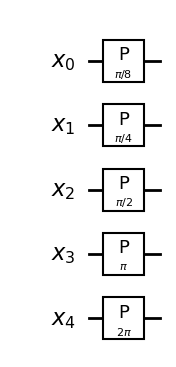

In [2]:
shors_alg.adder(2,15).draw(output="mpl", style="bw")

In [3]:
shors_alg.adder??

Signature: shors_alg.adder(a: int, N: int) -> qiskit.circuit.quantumcircuit.QuantumCircuit
Source:   
def adder(a: int, N: int) -> QuantumCircuit:
    """Returns the uncontrolled adder circuit.

    Parameters
    ----------
    a : int
        Positive integer strictly less than `N`
    N : int
        Positive integer, which Shor's algorithm factors

    Returns
    -------
    QuantumCircuit
        Unitary operator that takes in the state
            |phi(b)>_(n+1)
        and outputs the state
            |phi(a+b)>_(n+1)
    """
    # See Section 2.1 and Figure 3 of "Circuit for Shor's Algorithm
    # using 2n+3 qubits"

    # Must first "solve" for n, set up registers needed
    # Based off of cited paper, QC Bootcamp Problem Session 2's
    # implementation of Draper's adder circuit, and class lecture on
    # 22 May 2025

    # We utilize the corollary that relates the QFT, A_k (Draper),
    # and this (controlled) phase gate P_n(a) (phiADD(a))

    # "Solving" for n
    n = m

# Tests

In [4]:
# Set up for tests
# a == 2
# N == 15
# x == 11

a = 2
N = 15
x = 11

n = math.ceil(math.log2(N))

print(a, N, x, n)


2 15 11 4


## Adder

In [7]:
# Test adder
# Set b == 3
# If we compose QFT, adder, IQFT, we should get a+b=5
b = 3

# Quantum registers
b_qr = QuantumRegister(n+1, name="b")

adder_test_qc = QuantumCircuit(b_qr, name="adder test")

11
00011


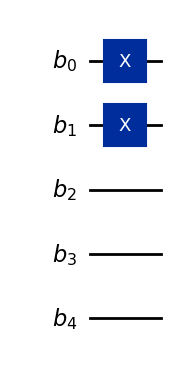

In [16]:
# Prepare state
# We should have b = 0011 in binary, so we prepare the state 1100
b_bin = bin(b)[2:]
print(b_bin)

b_bin = b_bin.zfill(n+1)
print(b_bin)

for i, bit in enumerate(b_bin):
    if int(bit) == 1:
        adder_test_qc.x(b_qr[n-i])

adder_test_qc.draw("mpl")

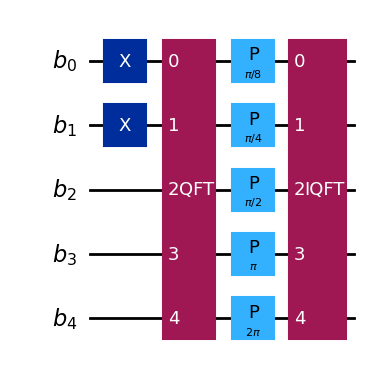

In [17]:
# Adder
adder_test_qc.compose(QFT(n+1).to_gate(), b_qr, inplace=True)
adder_test_qc.compose(shors_alg.adder(a,N), b_qr, inplace=True)
adder_test_qc.compose(QFT(n+1).inverse().to_gate(), b_qr, inplace=True)

adder_test_qc.draw("mpl")

In [19]:
# Measure output
adder_test_output = Statevector(adder_test_qc)
adder_test_prob_dict = adder_test_output.probabilities_dict()

# We should see a high probability for a+b = 5
# The likeliest state is thus 00101
print(bin(a+b))
adder_test_prob_dict.get("00101")

0b101


np.float64(0.999999999999998)

## Subtractor

11
00011


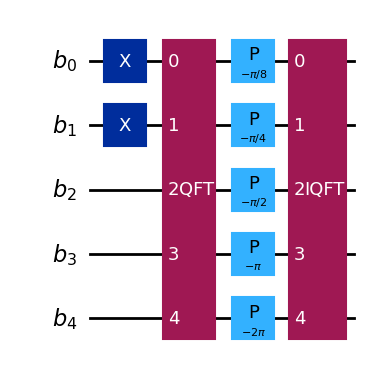

In [21]:
# Test subtractor
# With b=3, if we compose QFT, subtractor, IQFT, we should get b-a=1

subtractor_test_qc = QuantumCircuit(b_qr, name="subtractor test")

# Prepare state
# We should have b = 0011 in binary, so we prepare the state 1100
b_bin = bin(b)[2:]
print(b_bin)

b_bin = b_bin.zfill(n+1)
print(b_bin)

for i, bit in enumerate(b_bin):
    if int(bit) == 1:
        subtractor_test_qc.x(b_qr[n-i])

# Subtractor
subtractor_test_qc.compose(QFT(n+1).to_gate(), b_qr, inplace=True)
subtractor_test_qc.compose(shors_alg.subtractor(a,N), b_qr, inplace=True)
subtractor_test_qc.compose(QFT(n+1).inverse().to_gate(), b_qr, inplace=True)

subtractor_test_qc.draw("mpl")

In [ ]:
# Measure output
subtractor_test_output = Statevector(subtractor_test_qc)
subtractor_test_prob_dict = subtractor_test_output.probabilities_dict()

# We should see a high probability for b-a = 1
# The likeliest state is thus 00001
subtractor_test_prob_dict.get("00001")

np.float64(0.9999999999999978)

## Singly-controlled adder

In [24]:
#TODO

## Singly-controlled subtractor

In [25]:
#TODO

## Doubly-controlled adder

In [26]:
#TODO

## Doubly-controlled subtractor

In [27]:
#TODO

## Modular adder

### Controls $c_1 = c_2 = 1$

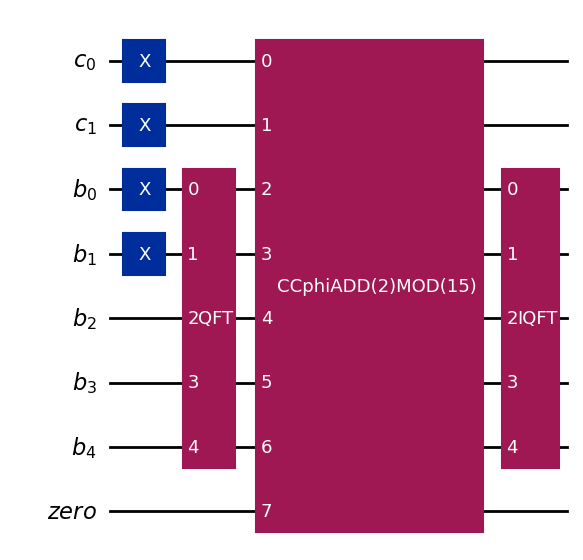

In [28]:
# Quantum registers
double_control_qr = QuantumRegister(2, name="c")
# already have b_qr
zero_qr = AncillaRegister(1, name="zero")

# Quantum circuit
modular_adder_test1_qc = QuantumCircuit(double_control_qr, b_qr, zero_qr, name="modular adder test 1")

# Prepare controls
modular_adder_test1_qc.x(double_control_qr[0])
modular_adder_test1_qc.x(double_control_qr[1])

# Prepare input state b=3
# We should have b = 0011 in binary, so we prepare the state 1100
for i, bit in enumerate(b_bin):
    if int(bit) == 1:
        modular_adder_test1_qc.x(b_qr[n-i])

# Modular adder
modular_adder_test1_qc.compose(QFT(n+1).to_gate(), b_qr, inplace=True)
modular_adder_test1_qc.compose(shors_alg.cc_adder_mod(a,N).to_gate(), qubits=[*double_control_qr, *b_qr, *zero_qr], inplace=True)
modular_adder_test1_qc.compose(QFT(n+1).inverse().to_gate(), b_qr, inplace=True)

modular_adder_test1_qc.draw("mpl")

In [32]:
# Measure output
modular_adder_test1_qc_output = Statevector(modular_adder_test1_qc)
modular_adder_test1_qc_prob_dict = modular_adder_test1_qc_output.probabilities_dict()

# We should see a high probability for a+b = 5
# The likeliest state is thus 00010111
print(bin(a+b))
modular_adder_test1_qc_prob_dict.get("00010111")

0b101


np.float64(3.257314884191114e-32)

## Inverse of modular adder

### Controls $c_1 = c_2 = 1$

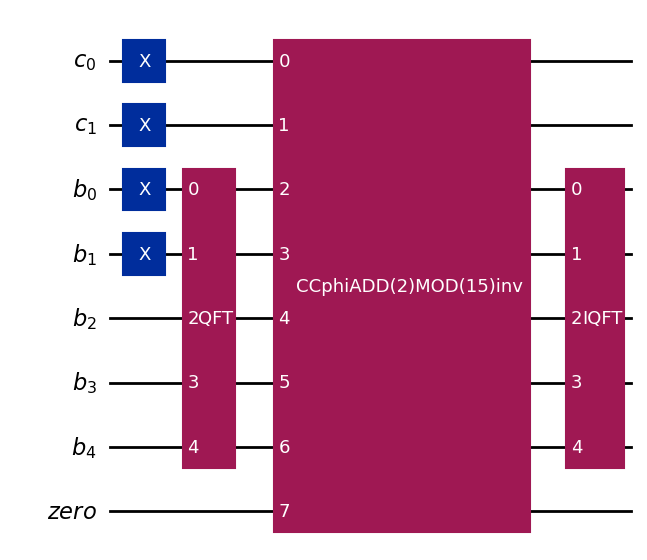

In [30]:
# Quantum circuit
modular_adder_inv_test1_qc = QuantumCircuit(double_control_qr, b_qr, zero_qr, name="modular adder inv test 1")

# Prepare controls
modular_adder_inv_test1_qc.x(double_control_qr[0])
modular_adder_inv_test1_qc.x(double_control_qr[1])

# Prepare input state b=3
# We should have b = 0011 in binary, so we prepare the state 1100
for i, bit in enumerate(b_bin):
    if int(bit) == 1:
        modular_adder_inv_test1_qc.x(b_qr[n-i])

# Modular adder inverse
modular_adder_inv_test1_qc.compose(QFT(n+1).to_gate(), b_qr, inplace=True)
modular_adder_inv_test1_qc.compose(shors_alg.cc_adder_mod_inv(a,N).to_gate(), qubits=[*double_control_qr, *b_qr, *zero_qr], inplace=True)
modular_adder_inv_test1_qc.compose(QFT(n+1).inverse().to_gate(), b_qr, inplace=True)

modular_adder_inv_test1_qc.draw("mpl")

## Controlled multiplier

## Inverse of controlled multiplier

In [ ]:
# Test with c == 0

# Quantum registers
control_qr = QuantumRegister(1, name="c")
input_qr = QuantumRegister(n, name="x")
ancilla = AncillaRegister(n+2, name="a")

# Quantum circuit
qc1 = QuantumCircuit(control_qr, input_qr, ancilla, name="test1")


In [6]:
# We already have c == 0
# Prepare input_qr with x == 11
x_bin = bin(x)[2:]
x_bin

'1011'

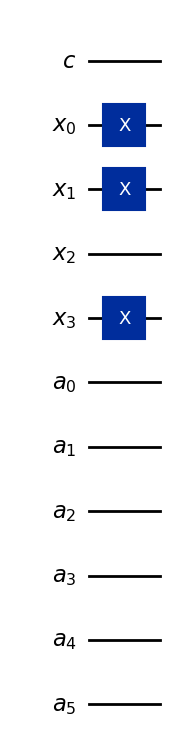

In [ ]:
# Prepare input_qr
# index 0 is the most significant bit in x_bin
# index 0 is the least significant bit in input_qr (according to Qiskit conventions)
for i, bit in enumerate(x_bin):
    if int(bit) == 1:
        qc1.x(input_qr[n-1-i])
qc1.draw("mpl")

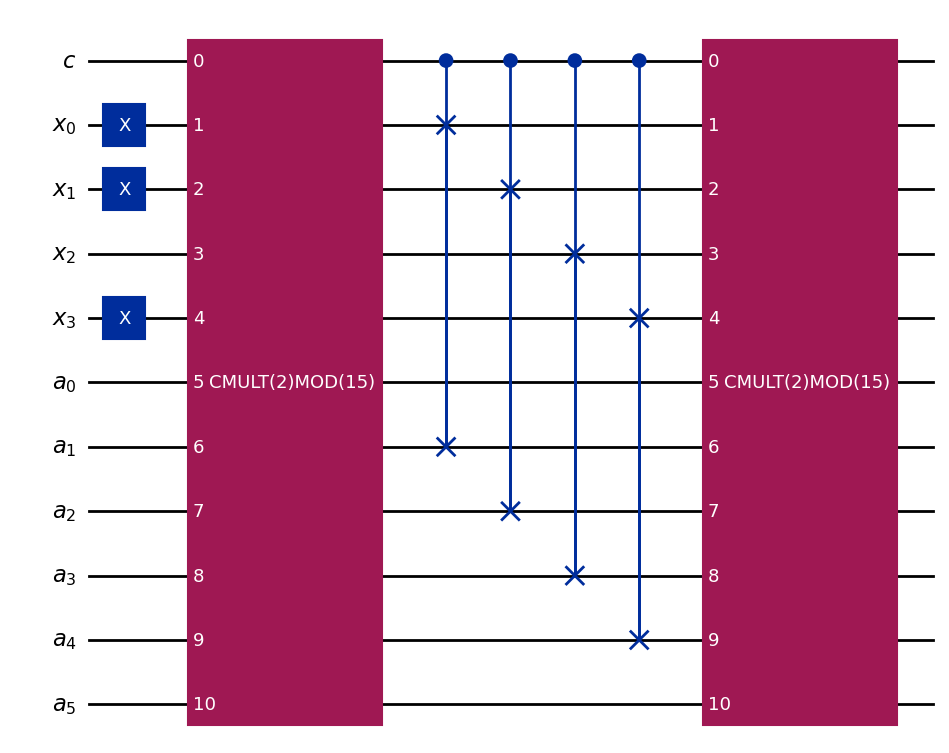

In [ ]:
# Add oracle gate
qc1.compose(shors_alg.oracle(a,N), 
           qubits=[*control_qr, *input_qr, *ancilla], 
           inplace=True)
qc1.draw("mpl")

In [ ]:
# Measure output
output = Statevector(qc1)
prob_dict = output.probabilities_dict()

# We should see high probability for x == 11
# Beware that the index of everything is flipped, so the control qubit is last
# We expect to see a high probability for the state "00000010110"
prob_dict.get("00000010110")

np.float64(0.9999999999999678)

In [12]:
# Test with c == 1
qc2 = QuantumCircuit(control_qr, input_qr, ancilla, name="test2")

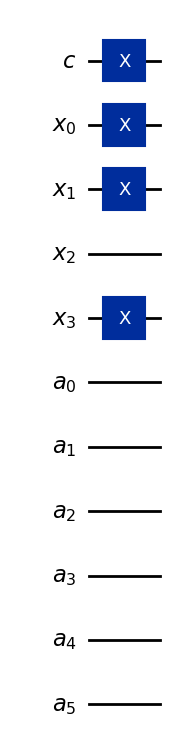

In [13]:
# Prepare control_qr with c == 1
qc2.x(control_qr)

# Prepare input_qr with x == 11
for i, bit in enumerate(x_bin):
    if int(bit) == 1:
        qc2.x(input_qr[n-1-i])

qc2.draw("mpl")


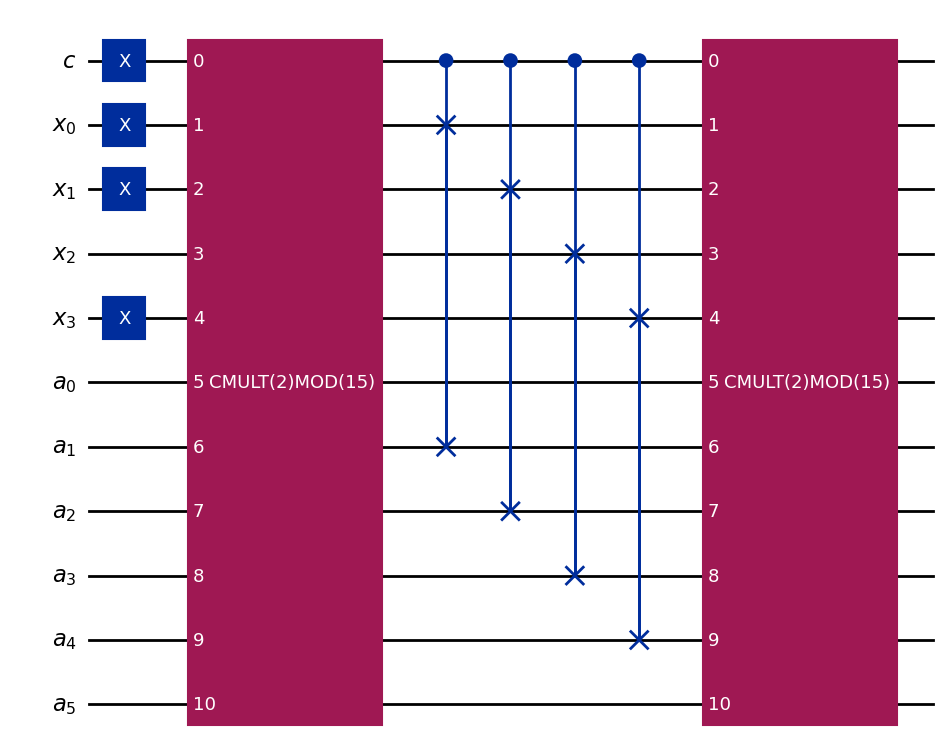

In [14]:
# Add oracle gate
qc2.compose(shors_alg.oracle(a,N), 
           qubits=[*control_qr, *input_qr, *ancilla], 
           inplace=True)
qc2.draw("mpl")

In [15]:
# Measure output
output = Statevector(qc2)
prob_dict = output.probabilities_dict()

In [16]:
# The output should be a*x mod N = 22 mod 15 = 7
a*x % N


7

In [17]:
bin(a*x % N)

'0b111'

In [18]:
# We expect the state "00000011101" to have high probability
prob_dict.get("00000011101")

np.float64(5.588917805828495e-60)

In [19]:
prob_dict

{np.str_('00000000001'): np.float64(1.2556546740657284e-60),
 np.str_('00000000011'): np.float64(5.896513481228336e-61),
 np.str_('00000000101'): np.float64(5.8620589085366466e-61),
 np.str_('00000000111'): np.float64(3.723442426447157e-61),
 np.str_('00000001001'): np.float64(8.873661439012775e-61),
 np.str_('00000001011'): np.float64(2.8641553218550227e-61),
 np.str_('00000001101'): np.float64(2.7440634616892126e-62),
 np.str_('00000001111'): np.float64(1.884101618600626e-62),
 np.str_('00000010001'): np.float64(3.6235426818652895e-62),
 np.str_('00000010011'): np.float64(4.375578853920538e-62),
 np.str_('00000010101'): np.float64(8.455667478974179e-62),
 np.str_('00000010111'): np.float64(7.83197501289991e-62),
 np.str_('00000011001'): np.float64(3.509685940337889e-60),
 np.str_('00000011011'): np.float64(4.013129155446234e-31),
 np.str_('00000011101'): np.float64(5.588917805828495e-60),
 np.str_('00000011111'): np.float64(2.7812258332515057e-61),
 np.str_('00000100001'): np.float64

In [20]:
max(prob_dict, key=prob_dict.get)

np.str_('11101111011')